In [1]:
import numpy as np

AR = np.random.rand(5,5)
AI = np.random.rand(5,5)
AR = AR + AR.T
AI = AI + AI.T
A = AR + 1j*AI
vr = np.random.rand(5)
vi = np.random.rand(5)
v = vr + 1j * vi
N = A.shape[0]

In [2]:
def to_real_rep(A):
    AR = A.real
    AI = A.imag
    A_eq = np.block([[AR, -AI], [-AI, -AR]])
    return A_eq


In [3]:
A_eq = np.block([[AR, -AI], [AI, AR]])
herm = 1/2 * (A.conj().T + A)
skewherm = 1/(2) * (A.conj().T - A)
A_eq = to_real_rep(A)
A_eq_i  = to_real_rep(-1j *A)
perm_mat = np.block([[np.zeros((N,N)), np.eye(N)], [-np.eye(N), np.zeros((N,N))]])
t1 = np.concatenate([v.real, v.imag])

select = np.diag([0 if i != 1 else 1 for i in range(2*N)])
Ai = np.diag([0 if i != 1 else 1 for i in range(N)]) @ A
hermi = select @ to_real_rep(A)

v.T@A @ v, t1.T @ A_eq @ t1, t1.T @ A_eq_i @ t1

(np.complex128(-6.432559341902044+9.163564499848547j),
 np.float64(-6.432559341902045),
 np.float64(9.16356449984855))

In [4]:
v.T@ np.diag([1 if i ==2 else 0 for i in range(N)]) @ A @ v

np.complex128(-1.158593347662594+1.9402489225487858j)

In [7]:
t1.T@ np.diag([1 if i ==2 or i == N+2 else 0 for i in range(2*N)]) @ A_eq @ t1

np.float64(-1.1585933476625938)

In [14]:
import pyomo.environ as pyo
model = pyo.ConcreteModel()
model.create_instance(filename="test.nl")
# model.
# test.read("test.nl")
model.display()

the create_instance() method of a concrete instance with name=None.
Model unknown

  Variables:
    None

  Objectives:
    None

  Constraints:
    None


<Axes: >

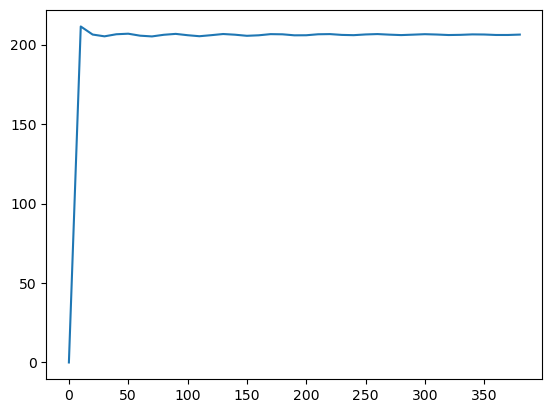

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

inmat = np.loadtxt('test')
inmat.shape
obj = inmat[:, 1]
time = inmat[:, 0]
sns.lineplot(x=time, y=obj)